In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from gammapy.datasets import Datasets, FluxPointsDataset
from gammapy.estimators import FluxPoints
from gammapy.modeling import Fit
from gammapy.modeling.models import SkyModel
from pathlib import Path
import sys

ROOT = Path("/Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet")
sys.path.insert(0, str(ROOT / "python"))

from bhjet import BHJet, BLJet
from bhjet.gammapy import BHJetSpectralModel

Setting BHJet parameters; all are included here, but there are defaults in the code, so this is not a necessary first step. 

In [2]:
bhjet_dyn = BLJet(
    mass_bh=1e9,
    jet_power_eddington=1e-5,
    z_jet_launching=2.0,
    r_initial=3.0,
    z_end_of_acceleration=1e5,
    z_dissipation=1e2,
    z_max_calculation=1e6,
    sigma_final=1.0,
    gamma_final=15.0,
    electron_temperature_jet_base=1e4,
    gamma_acceleration_exponent=0.5,
    opening_angle_constant=0.15,
    fraction_nonthermal_electrons=0.1,
    fraction_nonthermal_protons=0.1,
    factor_break_electrons=1.0,
    factor_break_protons=1.0,
    factor_max_energy_electrons=1.0,
    factor_max_energy_protons=1.0,
    index_injected_electrons=1.5,
    index_injected_protons=2.0,
    calc_pair_content_from_plasma_beta=False,
    plasma_beta_jet_base=0.2,
    dlgz=0.1,
    verbosity_level=0,
    cutoff_type=0,
)

bhjet_model = BHJet(
    theta_obs=17.0,
    distance=16e3,
    redshift=0.00428,
    include_counterjet=True,
    compton_threshold=1e-4,
    profile_time=False,
    verbosity_level=0,
)

bhjet_model.init_jet_dynamics(bhjet_dyn)

Load BHJet into the gammapy model template: 

In [3]:
gammapy_model = BHJetSpectralModel()
gammapy_model.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str29,float64,str1,float64,float64,float64,bool,str1,str1
,mass_bh,1.0000e+09,,0.000e+00,nan,nan,True,,
,jet_power_eddington,1.0000e-05,,0.000e+00,nan,nan,False,,
,z_jet_launching,2.0000e+00,,0.000e+00,nan,nan,True,,
,r_initial,3.0000e+00,,0.000e+00,nan,nan,False,,
,z_end_of_acceleration,1.0000e+05,,0.000e+00,nan,nan,False,,
,z_dissipation,1.0000e+02,,0.000e+00,nan,nan,False,,
,z_max_calculation,1.0000e+06,,0.000e+00,nan,nan,False,,
,sigma_final,1.0000e+00,,0.000e+00,nan,nan,False,,
,gamma_final,1.5000e+01,,0.000e+00,nan,nan,False,,


Verify that the parameters can be changed through the gammapy mode: 

In [4]:
gammapy_model.jet_power_eddington.value = 3e-5
gammapy_model.z_dissipation.value = 300.0
gammapy_model.index_injected_electrons.value = 2.0
gammapy_model.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str29,float64,str1,float64,float64,float64,bool,str1,str1
,mass_bh,1.0000e+09,,0.000e+00,nan,nan,True,,
,jet_power_eddington,3.0000e-05,,0.000e+00,nan,nan,False,,
,z_jet_launching,2.0000e+00,,0.000e+00,nan,nan,True,,
,r_initial,3.0000e+00,,0.000e+00,nan,nan,False,,
,z_end_of_acceleration,1.0000e+05,,0.000e+00,nan,nan,False,,
,z_dissipation,3.0000e+02,,0.000e+00,nan,nan,False,,
,z_max_calculation,1.0000e+06,,0.000e+00,nan,nan,False,,
,sigma_final,1.0000e+00,,0.000e+00,nan,nan,False,,
,gamma_final,1.5000e+01,,0.000e+00,nan,nan,False,,


Test this in the model calculation space as well: 

In [ ]:
energy = np.logspace(-8, 19, 200) * u.eV

gammapy_model.jet_power_eddington.value = 1e-5
flux_reference = gammapy_model(energy)

Manual Plotting:

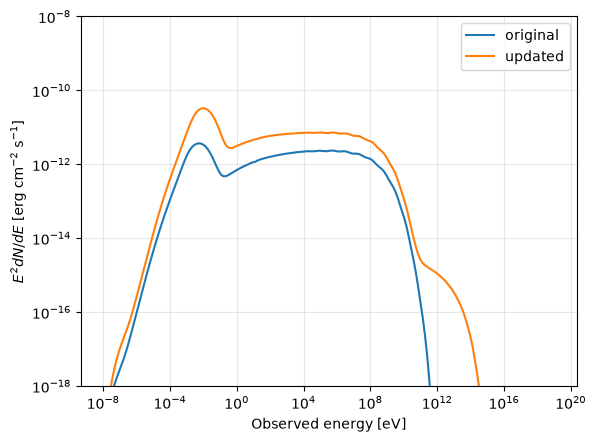

In [15]:
plt.loglog(
    energy.to_value(u.eV),
    (energy**2 * flux_reference).to_value("erg cm-2 s-1"),
    label="original",
)

plt.loglog(
    energy.to_value(u.eV),
    (energy**2 * flux_updated).to_value("erg cm-2 s-1"),
    label="updated",
)

plt.xlabel("Observed energy [eV]")
plt.ylabel(r"$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
plt.legend()
plt.ylim(1e-18, 1e-8)
plt.grid(alpha=0.3)

Note that the Compton threshold calculation selecting whether to compute the IC is visually apparent in this example - because the threshold is compared to the total jet power.

Using gammapy plotting functionality:

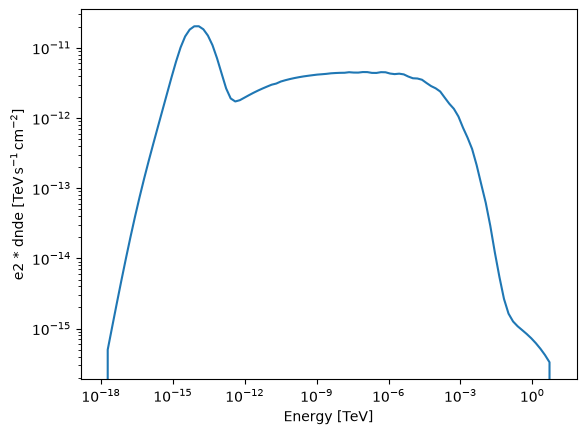

In [6]:
p=gammapy_model.plot(energy_bounds=[1E-18, 10] * u.TeV,energy_power=2)